## Estimate $C_L^{KK}$ from simple simulations, test general $<K(T_A, T_B) K(T_C, T_D)>$ estimator

This notebook goes through most of the basics of estimating $C_L^{KK}$. We do this one simple simulations
with Gaussian CMB and noise, and kSZ signal from the Alvarez 2015 simulations. 

We use the function `setup_recon_simple` to set up various stuff we need to estimate 
K (e.g. the filter functions, the quadratic estimator functions to apply to the filtered maps, theory N0s etc.).

We then generate simulations and apply these tools, ensuring that the recovery of $C_L^{KK}$ is consistent between:
- kSZ-only (i.e. no noise or CMB in the maps).
- the estimator is applied to maps with unlensed CMB and noise. 

In [1]:
import healpy as hp
import matplotlib
import matplotlib.pyplot as plt
import os
os.environ["DISABLE_MPI"]="true"
import numpy as np
from falafel import utils, qe
import pytempura
from pixell import lensing, curvedsky, enmap
from pixell import utils as putils
from os.path import join as opj
import argparse
import yaml
from collections import OrderedDict
from orphics import maps
import sys
from scipy.signal import savgol_filter
from ksz4 import setup_recon_simple, safe_mkdir, get_disable_mpi, get_cmb_alm_unlensed, ClBinner, get_cl_smooth

Set some options here for the K "reconstruction" and simulations. 
- lmin, lmax are the CMB temperature minimum and maximum l used 
- noise_sigma_X is the noise standard deviations 
for map X 

In [2]:
shape,wcs = enmap.fullsky_geometry(1.*putils.arcmin)
px=qe.pixelization(shape=shape,wcs=wcs)
mlmax=4000
lmin=3000
lmax=4000

#binning function for C_L^KK
binner=ClBinner(lmin=10, lmax=200, nbin=15)

Noise levels and beam for simulations

In [3]:
noise_sigma_X = 2.

#assume Gaussian beam with fwhm=1. arcmin
beam_fwhm=1.
ells = np.arange(mlmax+1)
beam = maps.gauss_beam(ells, beam_fwhm)
Nl_tt_X = (noise_sigma_X*np.pi/180./60.)**2./beam**2
nells_X = {"TT":Nl_tt_X, "EE":2*Nl_tt_X, "BB":2*Nl_tt_X}

#Get total noise using convenience function from falafel.utils
_,tcls_X = utils.get_theory_dicts(grad=True, nells=nells_X, lmax=mlmax)
_,tcls_nonoise = utils.get_theory_dicts(grad=True, lmax=mlmax)

Now download read in kSZ signal alms from Alvarez 2015 (https://arxiv.org/abs/1511.02846), we'll use these to
- add kSZ signal to the sims
- we'll also use the power spectrum in the filters 

In [12]:
#download alms using wget (I already converted the map to alms)
!wget -N https://portal.nersc.gov/project/act/maccrann/alms_4e3_2048_50_50_ksz_lmax4000.fits

--2025-02-12 02:36:13--  https://portal.nersc.gov/project/act/maccrann/alms_4e3_2048_50_50_ksz_lmax4000.fits
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.111, 128.55.206.110, 128.55.206.113, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.111|:443... connected.
200 OKequest sent, awaiting response... 
Length: 160128000 (153M) [image/fits]
Saving to: ‘alms_4e3_2048_50_50_ksz_lmax4000.fits’

alms_4e3_2048_50_50 100%[===================>] 152.71M   184MB/s    in 0.8s    

2025-02-12 02:36:14 (184 MB/s) - ‘alms_4e3_2048_50_50_ksz_lmax4000.fits’ saved [160128000/160128000]



In [4]:
#Read in alms
ksz_alm = utils.change_alm_lmax(hp.fitsfunc.read_alm("alms_4e3_2048_50_50_ksz_lmax4000.fits"),
                                mlmax)
cl_rksz = get_cl_smooth(ksz_alm)[:mlmax+1]
cltot_X = tcls_X['TT'][:mlmax+1] + cl_rksz

In [5]:
divide_by_2uL=False

simple_setup = setup_recon_simple(
    px, lmin, lmax,
    mlmax,  cl_rksz, cltot_X,
    do_lh=False, do_psh=False,
    divide_by_2uL=divide_by_2uL
)

First run the estimator on (filtered) kSZ-only alms. We use the `"qfunc_K"` and `"qfunc_K_AB"` entries of the 
setup dictionaries to estimate (normalised) `K`. Then use `alm2cl` to get $C_L^{KK}$ (note this won't be $N^0$ subtracted). 

Note that these quadratic estimator functions operate on *filtered maps*. The setup dictionaries also contain the filter functions. 

In [6]:
#do ksz only
Xf_ksz = simple_setup["filter"](ksz_alm.copy())

K_XX_kszonly = simple_setup["qfunc_K"](Xf_ksz, Xf_ksz)
cl_KK_XX_kszonly_raw = curvedsky.alm2cl(
    K_XX_kszonly
)

Get the $N^0$. `setup_recon_simple` already calculate the $N^0$ appropriate for maps with total noise `cltot_X`. But here we've run the etimator on a ksz-only map, so the $N^0$ will be different. Use the `get_fg_trispectrum_K_N0` entry of `simple_setup` to get $N^0$ for a map with some other noise - here `cl_rkz`. 

In [7]:
#also get ksz-only N0
N0_XX_kszonly = simple_setup["get_fg_trispectrum_K_N0"](
    cl_rksz
)
cl_KK_XX_kszonly = cl_KK_XX_kszonly_raw - N0_XX_kszonly

/global/cfs/projectdirs/act/data/maccrann/lenspipe_new/lib/python3.10/site-packages/ksz4/reconstruction.py:725: RuntimeWarning: invalid value encountered in divide
  N0_tri = N0_K**2 / norm_fg


## Generate simulations to test 
- recovery of signal 
- Analytic N0 calcualation (since this should agree with result of estimator on Gaussian sims)
Run on `nsim` simulations - can adjust this below.

In [8]:
from cmbsky.utils import get_cmb_alm_unlensed
nsim=1

cl_dict = {"KK_XX" : [],
           "KK_XX_gaussian" : [],
           "tcl_XX" : [],
          }
do_qe=True
rank,size=0,1

#Loop over nsim simulations
for isim in range(nsim):
    if size>1:
        if isim%size != rank-1:
            continue
    print("rank %d doing sim %d"%(rank,isim))
    print("reading cmb  alm")
    #get unlensed cmb (since lensed cmb will be biased - 
    #we'll deal with this later)
    cmb_alm_unlensed = curvedsky.rand_alm(tcls_nonoise["TT"], seed=isim*(10*nsim))
    cmb_alm_unlensed = utils.change_alm_lmax(cmb_alm_unlensed, mlmax)

    # Generate noise 
    # 
    print("generating noise")
    noise_alm_X = curvedsky.rand_alm(Nl_tt_X, seed=isim*(10*nsim)+1)

    X_ksz = ksz_alm.copy()
    X = cmb_alm_unlensed+noise_alm_X+ksz_alm
    cl_dict["tcl_XX"].append(
        curvedsky.alm2cl(X,X))
    Xf = simple_setup["filter"](X)

    ksz_alm_gaussian = curvedsky.rand_alm(cl_rksz, seed=isim*(10*nsim)+3)
    X_gaussian = cmb_alm_unlensed + noise_alm_X + ksz_alm_gaussian
    X_gaussianf = simple_setup["filter"](X_gaussian)
    
    #X_noksz = cmb_alm+noise_alm_X
    #Y_noksz = cmb_alm+noise_alm_Y
    #Xf_noksz, Yf_noksz = asym_setup["filter_X"](X_noksz), asym_setup["filter_Y"](Y_noksz)

    #X_fg_gaussian = curvedsky.rand_alm(cl_fg_X, seed=isim*(10*nsim)+3)
    #Y_fg_gaussian = 0.1*X_fg_gaussian

    print("running K estimators")
    if do_qe:
        print("qe case:")
        #K_XY = asym_setup["qfunc_K_XY"](Xf, Yf)
        #get signal
        K_XX = simple_setup["qfunc_K"](Xf,Xf)
        
        #also run on Gaussian sims to test N0
        K_XX_gaussian = simple_setup["qfunc_K"](
            X_gaussianf, X_gaussianf)
    
        cl_dict["KK_XX"].append(binner(
            curvedsky.alm2cl(K_XX)
        ))              
        cl_dict["KK_XX_gaussian"].append(binner(
            curvedsky.alm2cl(K_XX_gaussian)
        ))              
        
for key in cl_dict:
    cl_dict[key] = np.array(cl_dict[key])

rank 0 doing sim 0
reading cmb  alm
generating noise
running K estimators
qe case:


Compare mean recovered signal to kSZ-only case

Text(0, 0.5, '$C_L^{KK}$')

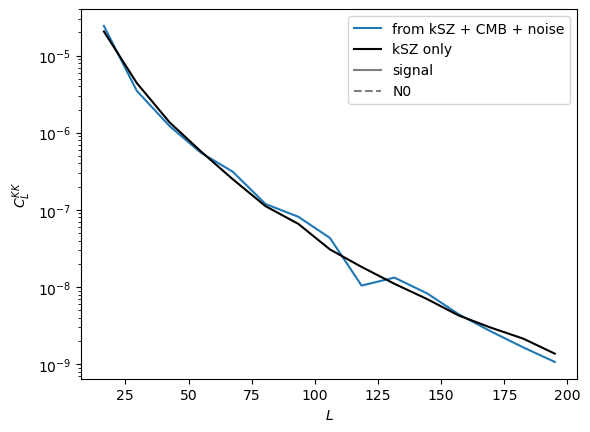

In [9]:
%matplotlib inline

fig,ax=plt.subplots()

cl_KK_XX = cl_dict["KK_XX"].mean(axis=0)  -  binner(simple_setup["N0_K"])

ax.plot(binner.bin_mids, cl_KK_XX, label="from kSZ + CMB + noise", color="C0")

ax.plot(binner.bin_mids, binner(cl_KK_XX_kszonly), label="kSZ only", color="k")
ax.plot([],[],"k-", alpha=0.5, label="signal")
ax.plot([],[],"k--",alpha=0.5, label="N0")

ax.legend()

ax.set_yscale('log')
ax.set_xlabel(r"$L$")
ax.set_ylabel(r"$C_L^{KK}$")

Compare $N^0$ calculated from Gaussian simulations to the analytic caclulation in `simple_setup`

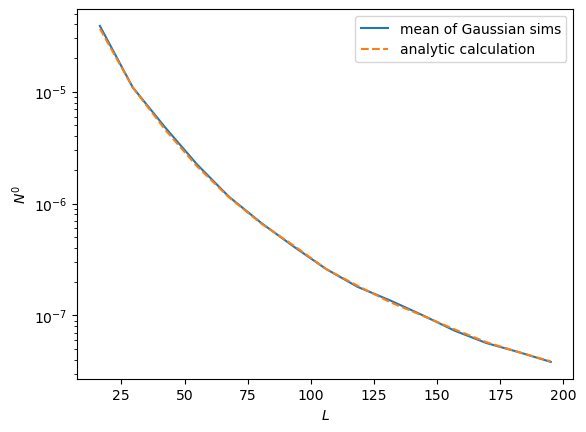

In [10]:
%matplotlib inline

fig,ax=plt.subplots()

ax.plot(binner.bin_mids, cl_dict["KK_XX_gaussian"].mean(axis=0), '-', color="C0", label="mean of Gaussian sims")
ax.plot(binner.bin_mids, binner(simple_setup["N0_K"]), '--', color="C1", label="analytic calculation")

ax.legend()
ax.set_xlabel(r"$L$")
ax.set_ylabel(r"$N^0$")
ax.set_yscale('log')